In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings

# Settings
warnings.filterwarnings('ignore')
sns.set(style="white", palette="muted")

In [3]:
# ==========================================
# 1. DATA LOADING & 1/4 SUBSAMPLING
# ==========================================
df_full = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Use 1/4 (25%) of the data
df = df_full.sample(frac=0.25, random_state=42).reset_index(drop=True)
print(f" Dataset Sampled to 1/4: {df.shape}")

 Dataset Sampled to 1/4: (135477, 8)


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,6/1/2011 12:05,0.85,17315.0,United Kingdom
1,554974,21128,GOLD FISHING GNOME,4,5/27/2011 17:14,6.95,14031.0,United Kingdom
2,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/2011 17:05,0.65,14031.0,United Kingdom
3,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/2011 10:39,1.95,17198.0,United Kingdom
4,546157,22180,RETROSPOT LAMP,2,3/10/2011 8:40,9.95,13502.0,United Kingdom


In [5]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
135472,573870,84974,S/2 ZINC HEART DESIGN PLANTERS,1,11/1/2011 12:25,9.95,14485.0,United Kingdom
135473,571241,72816,SET/3 CHRISTMAS DECOUPAGE CANDLES,1,10/14/2011 14:58,0.95,14592.0,United Kingdom
135474,563032,21407,BROWN CHECK CAT DOORSTOP,3,8/11/2011 14:39,4.25,16076.0,United Kingdom
135475,559526,23245,SET OF 3 REGENCY CAKE TINS,1,7/10/2011 11:19,4.95,15756.0,United Kingdom
135476,568228,22558,CLOTHES PEGS RETROSPOT PACK 24,12,9/26/2011 11:02,1.65,15358.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135477 entries, 0 to 135476
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    135477 non-null  object 
 1   StockCode    135477 non-null  object 
 2   Description  135119 non-null  object 
 3   Quantity     135477 non-null  int64  
 4   InvoiceDate  135477 non-null  object 
 5   UnitPrice    135477 non-null  float64
 6   CustomerID   101666 non-null  float64
 7   Country      135477 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 8.3+ MB


In [7]:
df_eda = df.copy()
df_eda['InvoiceDate'] = pd.to_datetime(df_eda['InvoiceDate'])
df_eda['Revenue'] = df_eda['Quantity'] * df_eda['UnitPrice']
df_eda['Hour'] = df_eda['InvoiceDate'].dt.hour
df_eda['Day'] = df_eda['InvoiceDate'].dt.day_name()
df_eda['Month'] = df_eda['InvoiceDate'].dt.month

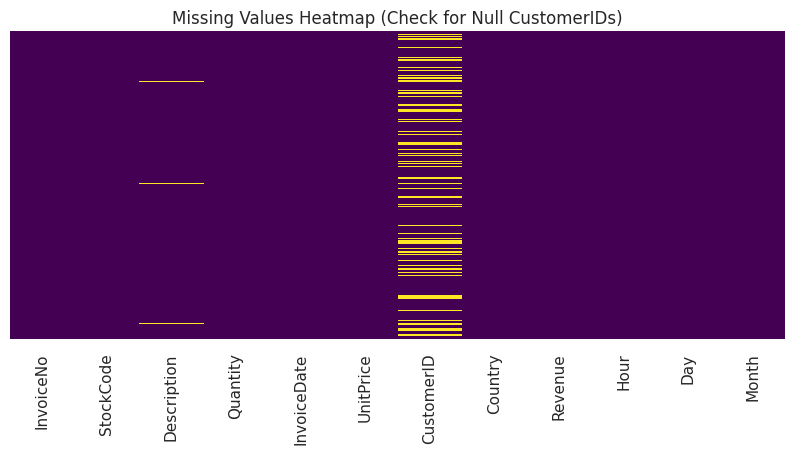

In [8]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_eda.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Check for Null CustomerIDs)')
plt.show()

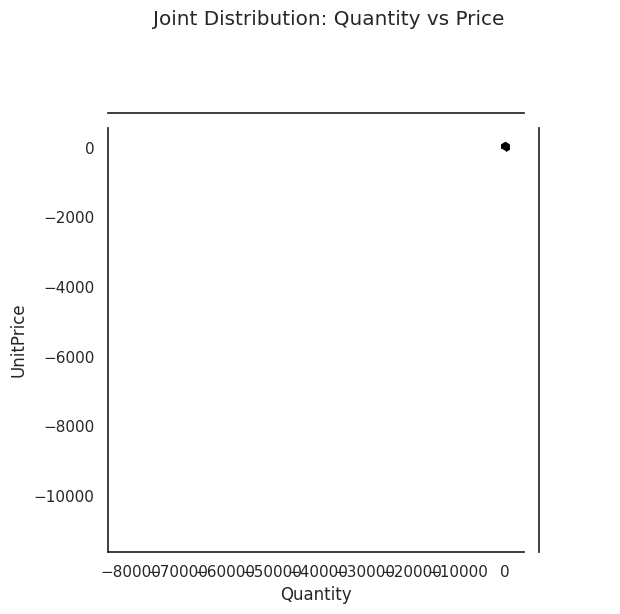

In [9]:
sns.jointplot(x='Quantity', y='UnitPrice', data=df_eda[(df_eda['Quantity']<100) & (df_eda['UnitPrice']<20)], kind='hex', color='blue')
plt.suptitle('Joint Distribution: Quantity vs Price', y=1.02)
plt.show()

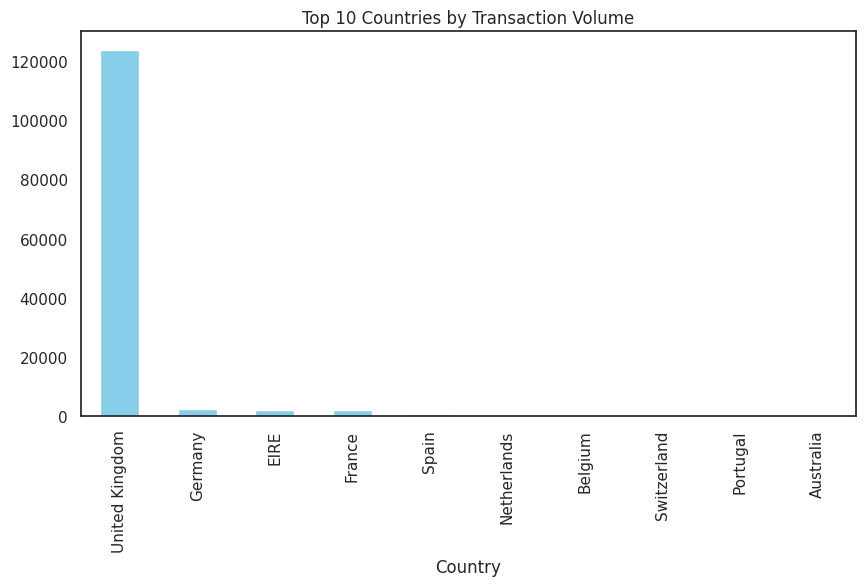

In [10]:
plt.figure(figsize=(10, 5))
df_eda['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Transaction Volume')
plt.show()

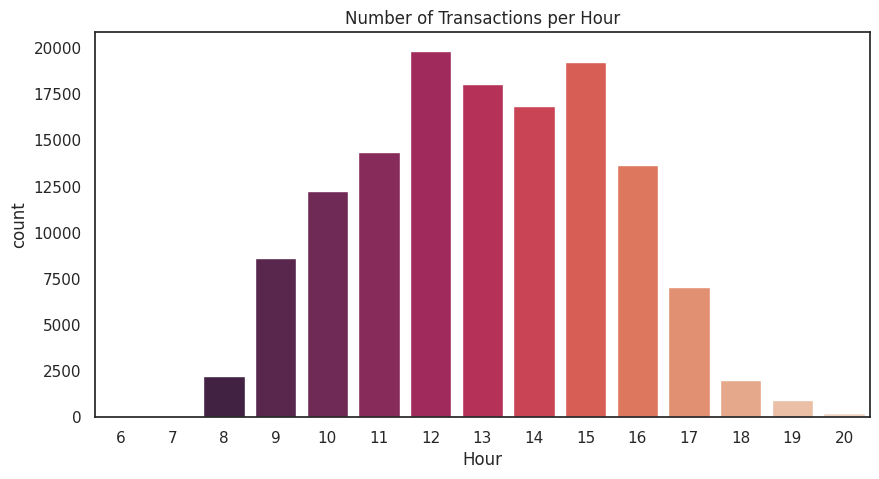

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Hour', data=df_eda, palette='rocket')
plt.title('Number of Transactions per Hour')
plt.show()

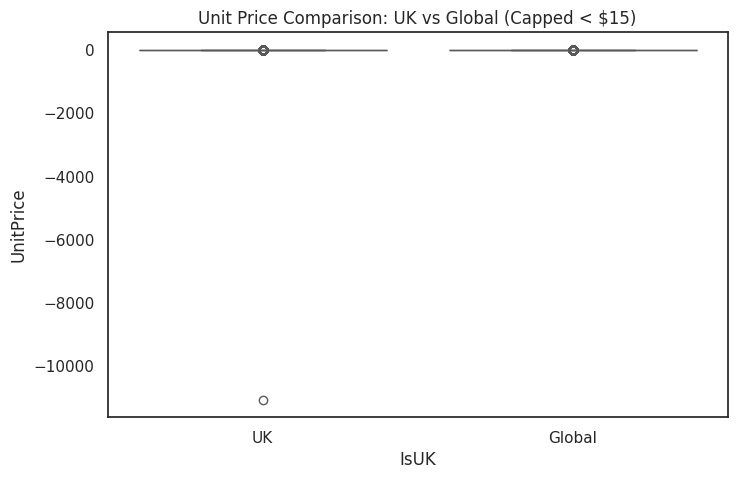

In [12]:
df_eda['IsUK'] = df_eda['Country'].apply(lambda x: 'UK' if x=='United Kingdom' else 'Global')
plt.figure(figsize=(8, 5))
sns.boxplot(x='IsUK', y='UnitPrice', data=df_eda[df_eda['UnitPrice'] < 15], palette='Set2')
plt.title('Unit Price Comparison: UK vs Global (Capped < $15)')
plt.show()

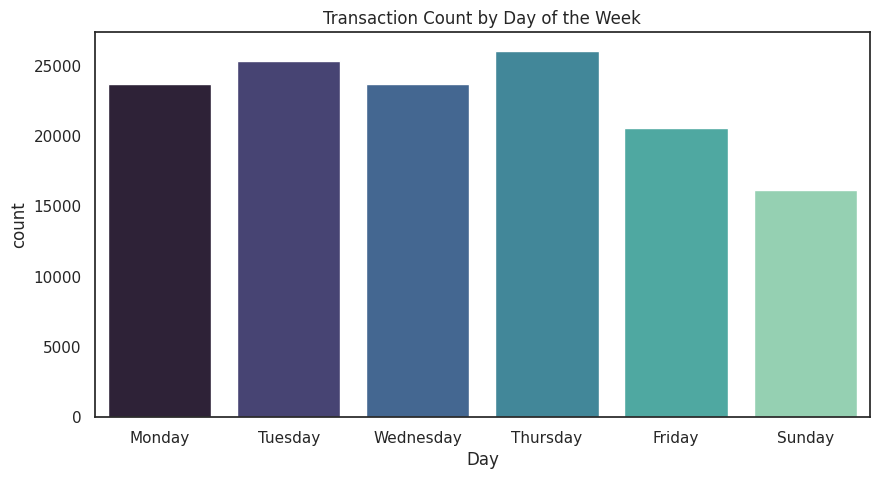

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Day', data=df_eda, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'], palette='mako')
plt.title('Transaction Count by Day of the Week')
plt.show()

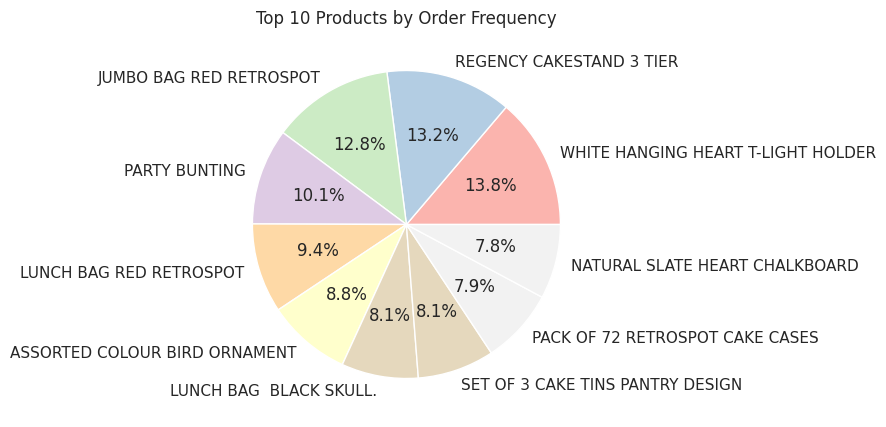

In [14]:
plt.figure(figsize=(10, 5))
df_eda['Description'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Top 10 Products by Order Frequency')
plt.ylabel('')
plt.show()

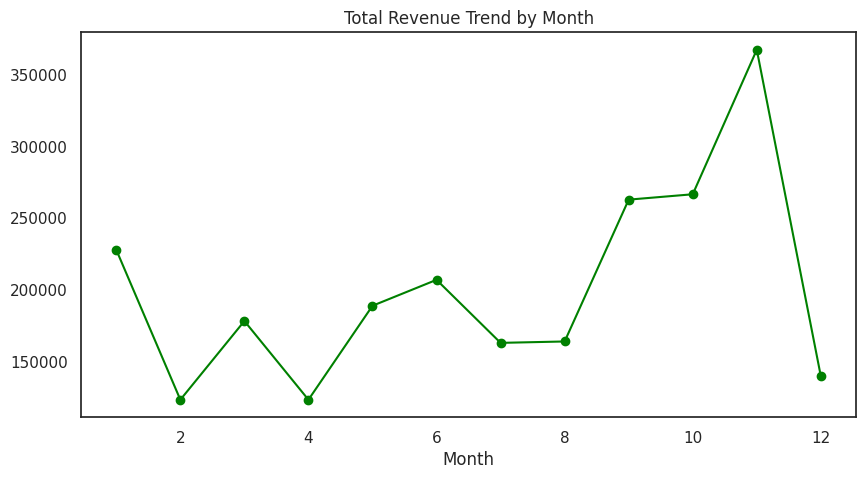

In [15]:
plt.figure(figsize=(10, 5))
df_eda.groupby('Month')['Revenue'].sum().plot(kind='line', marker='o', color='green')
plt.title('Total Revenue Trend by Month')
plt.show()

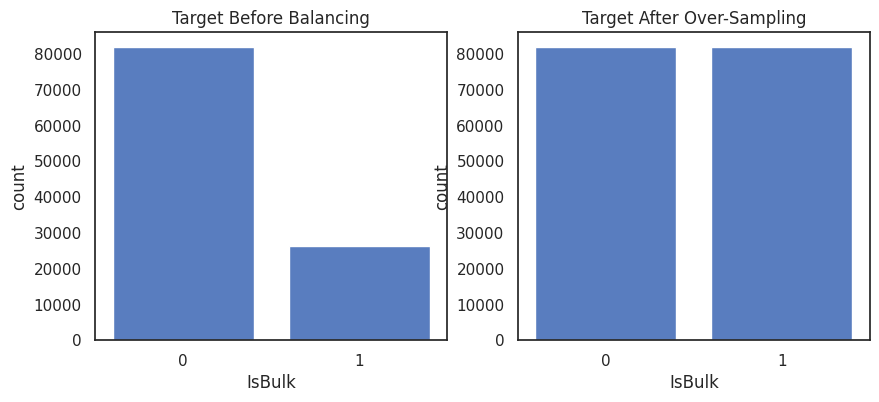

In [16]:
# ==========================================
# 3. PREPROCESSING & RANDOM OVER SAMPLING
# ==========================================
# Target: Predict if it's a "Bulk Order" (Quantity > 10)
df['IsBulk'] = (df['Quantity'] > 10).astype(int)
X = df[['UnitPrice', 'CustomerID']].fillna(0)
y = df['IsBulk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MANUAL RANDOM OVER SAMPLING ---
train_data = pd.concat([X_train, y_train], axis=1)
maj_class = train_data[train_data['IsBulk'] == 0]
min_class = train_data[train_data['IsBulk'] == 1]

min_upsampled = min_class.sample(len(maj_class), replace=True, random_state=42)
balanced_df = pd.concat([maj_class, min_upsampled]).sample(frac=1)

X_train_res = balanced_df.drop('IsBulk', axis=1)
y_train_res = balanced_df['IsBulk']

# Visualizing Sampling
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Target Before Balancing')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res)
plt.title('Target After Over-Sampling')
plt.show()

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [17]:
# ==========================================
# 4. 3 ML MODELS & RANKING
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=10)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    preds = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

In [18]:
# Ranking
rank_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
rank_df.index += 1
print("\n- MODEL PERFORMANCE ---")
print(rank_df)


- MODEL PERFORMANCE ---
                 Model  Accuracy  F1-Score
1        Decision Tree  0.775686  0.630157
2        Random Forest  0.775022  0.630769
3  Logistic Regression  0.652827  0.551428


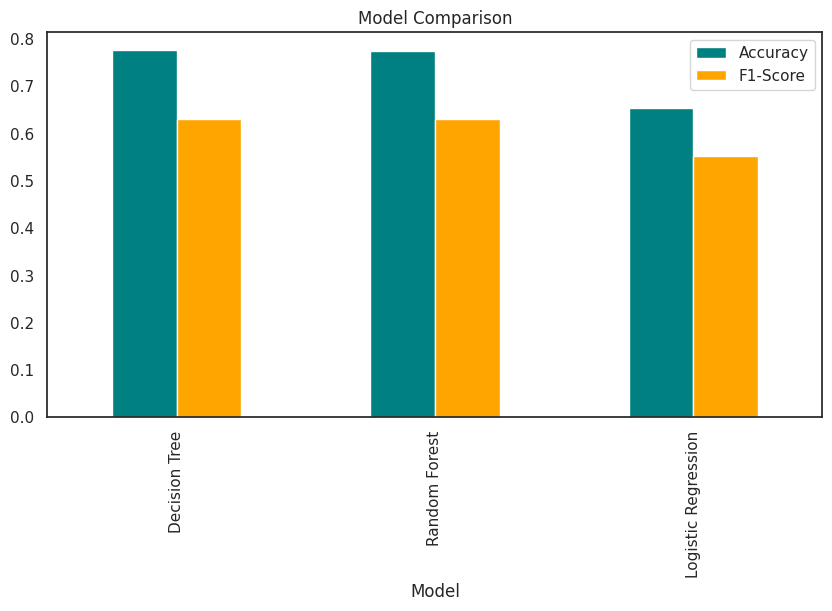

In [19]:
# Final comparison
rank_df.set_index('Model')[['Accuracy', 'F1-Score']].plot(kind='bar', figsize=(10,5), color=['teal', 'orange'])
plt.title('Model Comparison')
plt.show()